# **Assignment 7: Multiple Linear Regression (Toyota Corolla Price Prediction)**

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# **Task 1: Exploratory Data Analysis & Preprocessing**

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB
None

--- Summary Statistics ---
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.

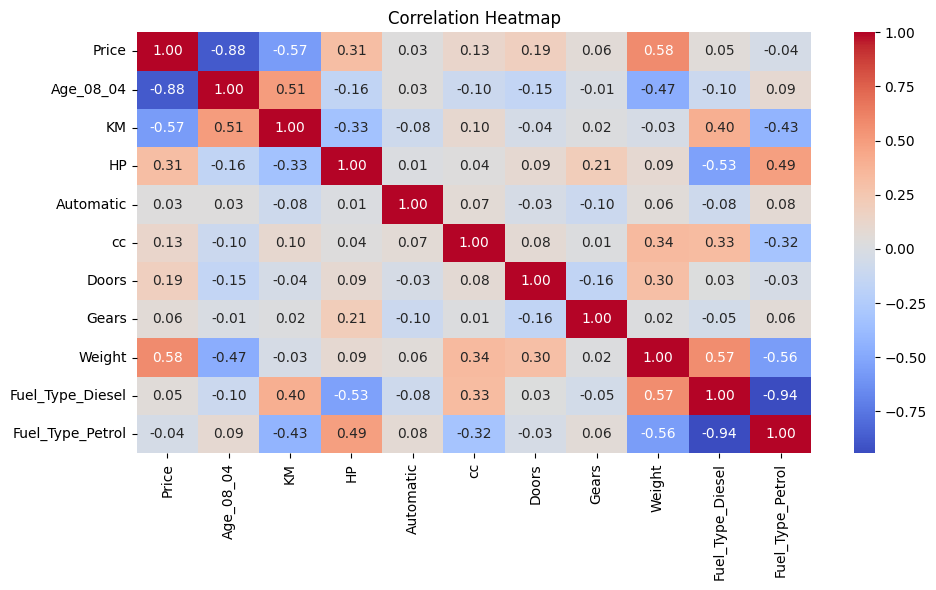

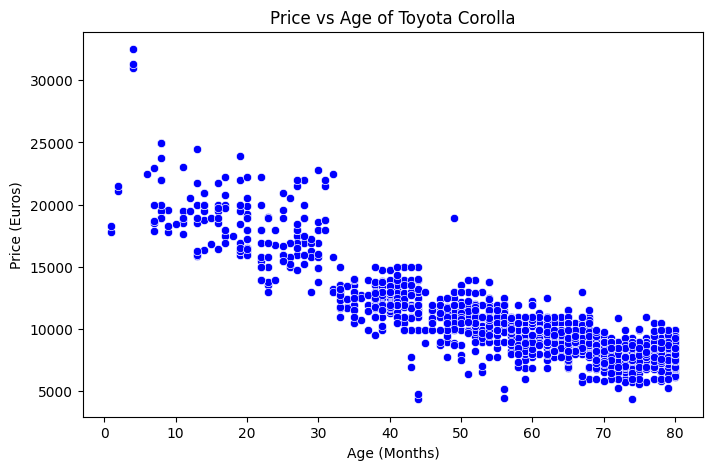

In [12]:
# Load dataset
df = pd.read_csv("/content/ToyotaCorolla - MLR.csv")

print("--- Dataset Information ---")
print(df.info())

print("\n--- Summary Statistics ---")
print(df.describe())

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop constant columns if any (e.g., Cylinders is 4 for all records)
if "Cylinders" in df.columns:
    df = df.drop(columns=["Cylinders"])

# One-Hot Encoding for categorical feature 'Fuel_Type'
df_encoded = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

# Visualizations
plt.figure(figsize=(10, 6))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="Age_08_04", y="Price", data=df_encoded, color="blue")
plt.title("Price vs Age of Toyota Corolla")
plt.xlabel("Age (Months)")
plt.ylabel("Price (Euros)")
plt.show()

# **Task 2: Dataset Splitting**

In [13]:
X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features for Regularization Models (Ridge & Lasso)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Task 3: Build & Interpret 3 Different MLR Models**

In [14]:
# Model 1: Full Baseline Model (All Features)
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("--- Model 1: Full Feature Set Coefficients ---")
for col, coef in zip(X.columns, model1.coef_):
    print(f"{col}: {coef:.4f}")
print(f"Intercept: {model1.intercept_:.4f}\n")

# Model 2: Key Predictors (Age_08_04, KM, HP, Weight)
cols2 = ["Age_08_04", "KM", "HP", "Weight"]
model2 = LinearRegression()
model2.fit(X_train[cols2], y_train)

# Model 3: Key Predictors + Engine Specs (Age_08_04, KM, HP, Weight, cc, Automatic)
cols3 = ["Age_08_04", "KM", "HP", "Weight", "cc", "Automatic"]
model3 = LinearRegression()
model3.fit(X_train[cols3], y_train)

--- Model 1: Full Feature Set Coefficients ---
Age_08_04: -120.8305
KM: -0.0162
HP: 14.0395
Automatic: 148.8309
cc: -0.0304
Doors: -60.3110
Gears: 551.6007
Weight: 25.8850
Fuel_Type_Diesel: -68.5488
Fuel_Type_Petrol: 1370.8089
Intercept: -14255.3860



LinearRegression()

# **Task 4: Model Evaluation**

In [15]:
def evaluate_model(model, X_test_data, y_true, name):
    y_pred = model.predict(X_test_data)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"--- {name} ---")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}\n")


evaluate_model(model1, X_test, y_test, "Model 1 (All Features)")
evaluate_model(model2, X_test[cols2], y_test, "Model 2 (4 Key Features)")
evaluate_model(model3, X_test[cols3], y_test, "Model 3 (6 Select Features)")

--- Model 1 (All Features) ---
R² Score: 0.8349
RMSE: 1484.2654

--- Model 2 (4 Key Features) ---
R² Score: 0.8506
RMSE: 1411.8502

--- Model 3 (6 Select Features) ---
R² Score: 0.8510
RMSE: 1410.0823



# **Task 5: Ridge & Lasso Regularization**

In [16]:
# Ridge Regression
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
evaluate_model(ridge, X_test_scaled, y_test, "Ridge Regression (alpha=10.0)")

# Lasso Regression
lasso = Lasso(alpha=10.0)
lasso.fit(X_train_scaled, y_train)
evaluate_model(lasso, X_test_scaled, y_test, "Lasso Regression (alpha=10.0)")

--- Ridge Regression (alpha=10.0) ---
R² Score: 0.8363
RMSE: 1477.6898

--- Lasso Regression (alpha=10.0) ---
R² Score: 0.8371
RMSE: 1474.2550

